In [1]:
# Import dependencies
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from urllib.request import urlopen
from itertools import compress, combinations, chain

In [2]:
# Custom string replacement method
def replace_multiple(string, mapping, separator):
    # String replacement
    for old, new in mapping.items():
        string = string.replace(old, new)
    # Sort and rejoin
    split_string = string.split(separator)
    string = ', '.join(sorted(split_string))
    return string

In [3]:
# Load TACTIC data
link = 'https://www.dropbox.com/scl/fi/75x56c2xg2za3i62py9sb/TACTIC_data.pkl?rlkey=d3yq4l0o4o6isj9ott6p2f935&st=yvradv4b&dl=1'
ecoli, mtb, master, out = pickle.load(urlopen(link))

# Read data files
path = './data/LarkinsFord/'
files = os.listdir(path)
data = dict()
for file in files:
    index = file.split('.')[0]
    if file.startswith('Abb'):
        df = pd.read_excel(path + file, sheet_name=None)
        for key, value in df.items():
            df[key] = dict(zip(value.iloc[:, 0], value.iloc[:, 1]))
    else:
        df = pd.read_excel(path + file)
        if file.startswith('IC'):
            df = df.iloc[:, :-1].dropna().set_index(df.columns[0]).replace('ND', np.nan)
        else:
            df = df.rename(columns={'in vitro model': 'in vitro models', 'time point': 'time points'})
    data[index] = df.copy()

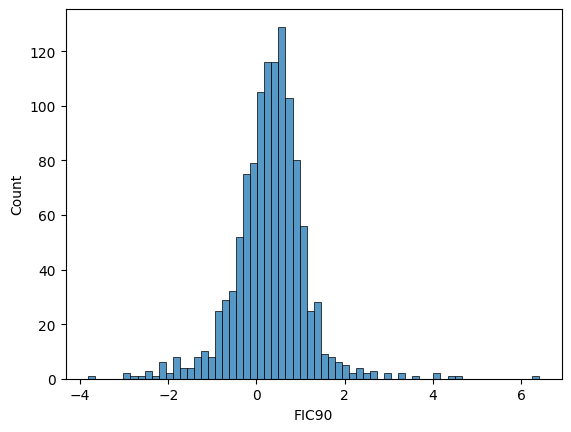

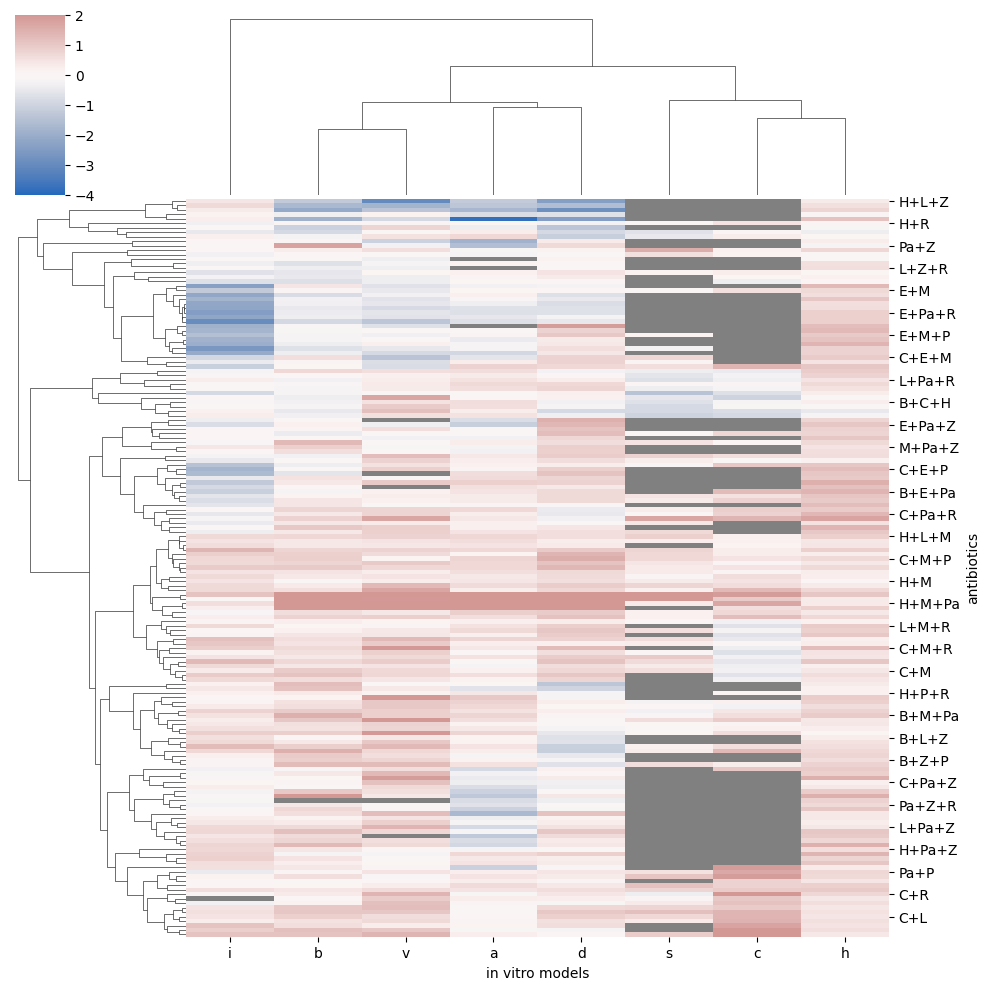

In [4]:
# Inspect treatment outcomes at terminal time point
df = data['Data Cube'].copy()
df = df[df['time points'].str.contains('T')]
# df['FIC90'] = np.log2(df['FIC90'] + 1)
sns.histplot(data=df, x='FIC90')
x = pd.pivot_table(df, index='antibiotics', columns='in vitro models', values='FIC90')
cg = sns.clustermap(data=x.fillna(x.mean()), metric='cosine', mask=x.isnull(), center=0, cmap='vlag', vmin=-4, vmax=2)
cg.ax_heatmap.collections[0].cmap.set_bad('grey') 


In [5]:
# Inspect M. tb data already in TACTIC
df = master['data'].copy()
dfm = df[df['Strain'].str.startswith('M. tuberculosis')]
print(f'Total number of entries for M. tb: {dfm.shape[0]}')
print(dfm['Strain'].value_counts())
print(dfm['Source'].value_counts())

# Define keys from respective sets
k1 = data['Abbreviations']['antibiotics'].copy()
k2 = {
    'BDQ': 'bedaquiline', 
    'CFZ': 'clofazimine', 
    'EMBx': 'ethambutol', 
    'INH': 'isoniazid', 
    'LZDx': 'linezolid', 
    'MOX': 'moxifloxacin', 
    'PA824': 'pretomanid', 
    'PZA': 'pyrazinamide', 
    'RIF': 'rifampicin', 
    'RIFP': 'rifapentine'
}

# Define in vitro model
model = 's'

Total number of entries for M. tb: 543
Strain
M. tuberculosis H37Rv         389
M. tuberculosis ATCC 35801    154
Name: count, dtype: int64
Source
8     230
11    154
12    120
19     14
17      9
18      6
15      4
13      3
16      2
14      1
Name: count, dtype: int64


No. of missing entries in h model: 0
Total no. of ixns: 230
No. of unique ixns: 181
No. of overlapping ixns: 43
No. of comparable ixns: 43
Total counts based on ixn degree:
2    28
3    15
Name: count, dtype: int64

No. of missing entries in h model: 0
Total no. of ixns: 154
No. of unique ixns: 148
No. of overlapping ixns: 12
No. of comparable ixns: 12
Total counts based on ixn degree:
2    12
Name: count, dtype: int64

No. of missing entries in h model: 0
Total no. of ixns: 120
No. of unique ixns: 120
No. of overlapping ixns: 10
No. of comparable ixns: 10
Total counts based on ixn degree:
2    10
Name: count, dtype: int64



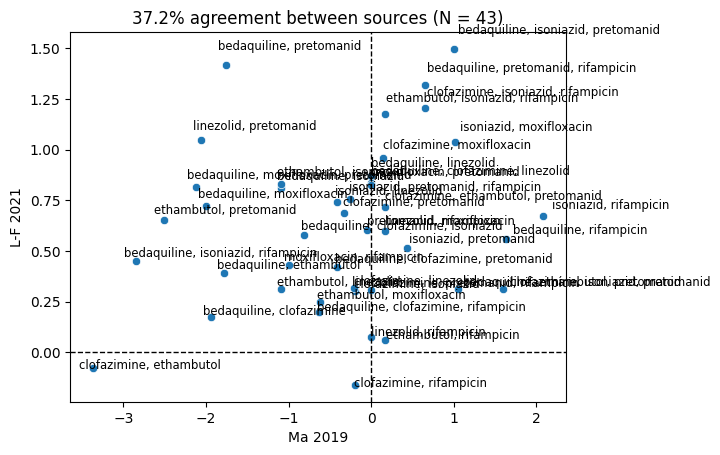

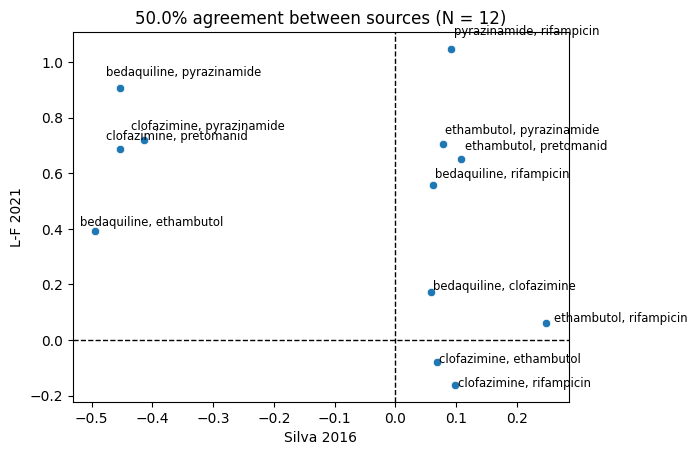

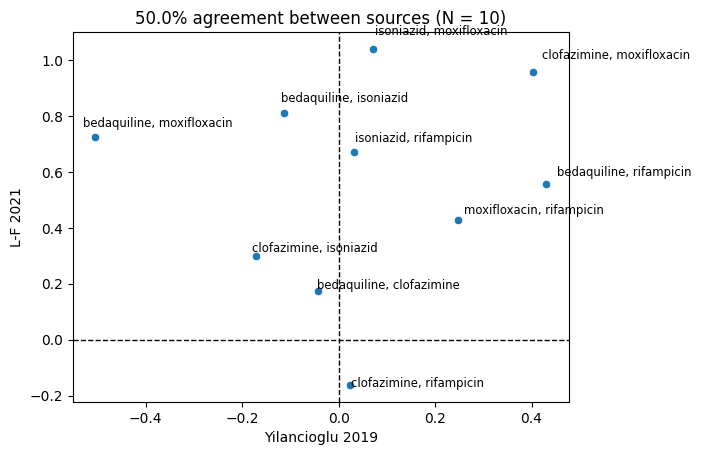

In [7]:
# Define in vitro model
model = 'h'

# Define data sources
sources = {8: 'Ma 2019', 11: 'Silva 2016', 12: 'Yilancioglu 2019'}

# Run comparisons
for source, ref in sources.items():
    # Define data sets
    df1 = x[model].copy()
    print(f'No. of missing entries in {model} model: {df1.isnull().sum()}')
    df2 = df[df['Source']==source]
    print(f'Total no. of ixns: {df2.shape[0]}')
    df2 = df2.groupby('Interaction')['Score'].mean()
    print(f'No. of unique ixns: {df2.shape[0]}')

    # Convert interaction lists
    ixns1 = {replace_multiple(s, k1, '+') for s in df1.index}
    ixns2 = {replace_multiple(s, k2, ', ') for s in df2.index}
    ixns = ixns1 & ixns2
    print(f'No. of overlapping ixns: {len(ixns)}')

    # Reset index of dataframes
    df1.index = list(ixns1)
    df2.index = list(ixns2)

    # Intersection
    dfi = pd.concat([df1.loc[list(ixns)], df2.loc[list(ixns)]], axis=1)
    dfi.columns = ['L-F 2021', ref]
    dfi = dfi.dropna()
    print(f'No. of comparable ixns: {dfi.shape[0]}')

    # Agreement calculation
    dfb = dfi > 0
    agree = (dfb.iloc[:, 0] == dfb.iloc[:, 1]).sum() / dfb.shape[0]

    # Visualize scatter plot
    plt.figure()
    ax = sns.scatterplot(data=dfi, x=ref, y='L-F 2021')
    for i, point in dfi.iterrows():
        ax.text(point[ref]*1.05, point['L-F 2021']*1.05, i, 
                horizontalalignment='left', size='small', color='black')
    ax.set_title(f'{100*agree:.1f}% agreement between sources (N = {dfi.shape[0]})')
    ax.axhline(0, ls='--', lw=1, color='k')
    ax.axvline(0, ls='--', lw=1, color='k')
        
    # Print total number of intersections
    counts = pd.Series([s.count(',') + 1 for s in ixns]).value_counts()
    print(f'Total counts based on ixn degree:\n{counts}\n')

In [9]:
# Isolate standard ixns
k3 = {v: k for k, v in k2.items()}
df = data['Data Cube'].copy()
dfe = df[(df['in vitro models']=='s') & (df['time points'].str.contains('T')) & df['antibiotics'].str.contains('\\+')][['antibiotics', 'FIC90']]
dfe['interaction'] = [replace_multiple(s, k1, '+') for s in dfe['antibiotics']]
dfe['interaction'] = [replace_multiple(s, k3, ', ') for s in dfe['interaction']]
dfe.dropna().to_excel('./data/LF_standard.xlsx')